# Data Loader

## Choose data path
Update this to your new dataset file.

In [1]:
TRAIN_PATH = r"../../../datasets/setpoint_mixed_V5_mixed_formations_train.pt"
VAL_PATH = r"../../../datasets/setpoint_mixed_V5_mixed_formations_val.pt"
TEST_PATH = r"../../../datasets/setpoint_mixed_V5_mixed_formations_test.pt"

## Load data


In [2]:
from pathlib import Path
import json
import numpy as np
import torch

train_path = Path(TRAIN_PATH).expanduser().resolve()
val_path = Path(VAL_PATH).expanduser().resolve()
test_path = Path(TEST_PATH).expanduser().resolve()

print("Loading:", train_path)
payload1 = torch.load(train_path, weights_only=False)


print("Loading:", val_path)
payload2 = torch.load(val_path, weights_only=False)


print("Loading:", test_path)
payload3 = torch.load(test_path, weights_only=False)


Loading: C:\Users\aimen\OneDrive\Desktop\gnn_drone_project\datasets\setpoint_mixed_V5_mixed_formations_train.pt


c:\Users\aimen\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading: C:\Users\aimen\OneDrive\Desktop\gnn_drone_project\datasets\setpoint_mixed_V5_mixed_formations_val.pt
Loading: C:\Users\aimen\OneDrive\Desktop\gnn_drone_project\datasets\setpoint_mixed_V5_mixed_formations_test.pt


## Dataset summary


In [3]:
from pathlib import Path
import torch

def count_graphs_episodes(payload):
    graphs = None
    episodes = None
    if isinstance(payload, dict) and "slices" in payload and "data" in payload:
        first_key = next(iter(payload["slices"]))
        graphs = len(payload["slices"][first_key]) - 1
        if "episode_id" in payload["slices"] and hasattr(payload["data"], "episode_id"):
            ep = payload["data"].episode_id
            sl = payload["slices"]["episode_id"]
            ids = [int(ep[sl[i]]) for i in range(len(sl) - 1)]
            episodes = len(set(ids))
    return graphs, episodes

payloads = {}
payloads["train"] = payload1
payloads["val"] = payload2
payloads["test"] = payload3


for name in ["train", "val", "test"]:
    graphs, episodes = count_graphs_episodes(payloads[name])
    print(f"{name}: graphs={graphs} episodes={episodes}")

train: graphs=15525 episodes=160
val: graphs=2104 episodes=20
test: graphs=2277 episodes=20


## First graph structure


In [4]:
import torch

def extract_graph(payload, idx=0):
    data = payload["data"]
    slices = payload["slices"]
    graph = {}
    for key, sl in slices.items():
        if not hasattr(data, key):
            continue
        item = getattr(data, key)
        graph[key] = item[sl[idx]:sl[idx + 1]]
    return graph


def print_graph_structure(graph):
    for key, value in graph.items():
        if torch.is_tensor(value):
            print(f"{key}: shape={tuple(value.shape)} dtype={value.dtype}")
        else:
            print(f"{key}: type={type(value)}")



train_payload = payload1
if isinstance(train_payload, dict) and "data" in train_payload and "slices" in train_payload:
    graph0 = extract_graph(train_payload, 0)
    print_graph_structure(graph0)
else:
    print("Train payload not in expected format.")

x: shape=(17, 64) dtype=torch.float32
edge_index: shape=(2, 1799314) dtype=torch.int64
edge_attr: shape=(130, 7) dtype=torch.float32
pos: shape=(17, 3) dtype=torch.float32
target: shape=(17, 4) dtype=torch.float32
obstacles: shape=(5, 3) dtype=torch.float32
formation_id: shape=(1,) dtype=torch.int64
episode_id: shape=(1,) dtype=torch.int64
step_idx: shape=(1,) dtype=torch.int64
num_drones: shape=(1,) dtype=torch.int64


### Feature, labels (target), and edge attr walkthrough

In [6]:
import torch

def first_graph(payload, idx=7):
    data = payload["data"]
    slices = payload["slices"]
    graph = {}
    for key, sl in slices.items():
        if not hasattr(data, key):
            continue
        item = getattr(data, key)
        graph[key] = item[sl[idx]:sl[idx + 1]]
    return graph

train_payload = payload1
graph0 = first_graph(train_payload, 0)

x = graph0.get("x")
target = graph0.get("target")
edge_attr = graph0.get("edge_attr")

formation_names = list(train_payload.get("formation_names", ["a", "rectangle", "triangle", "random_cloud"]))
obs_names = [f"obs_{i}" for i in range(16)]
# --- Single-frame feature names (before stacking) ---
single_frame_features = [
    "local_linear_vel_x", "local_linear_vel_y", "local_linear_vel_z",
    "local_angular_vel_x", "local_angular_vel_y", "local_angular_vel_z",
    *obs_names,
    "local_target_error_x", "local_target_error_y", "local_target_error_z", "local_target_error_yaw",
    "distance_to_floor", "distance_to_ceiling",
    *[f"form_{name}" for name in formation_names],
]
single_frame_dim = len(single_frame_features)

# Frame stacking (k=2): [x_t, x_{t-1}]
feature_names = (
    [f"t0_{name}" for name in single_frame_features]
    + [f"t1_{name}" for name in single_frame_features]
)
label_names = ["dx_local", "dy_local", "dz_local", "dyaw"]
edge_names = ["rel_x", "rel_y", "rel_z", "dist", "rel_vx", "rel_vy", "rel_vz"]

if torch.is_tensor(x):
    num_features = x.shape[1]
    if len(feature_names) > num_features:
        feature_names = feature_names[:num_features]
    elif len(feature_names) < num_features:
        feature_names = feature_names + [f"feature_{i}" for i in range(len(feature_names), num_features)]
    print("Drone features (x):")
    for i in range(x.shape[1]):
        name = feature_names[i] if i < len(feature_names) else f"feature_{i}"
        print(f"  [{i}] {name}")

if torch.is_tensor(target):
    if len(label_names) > target.shape[1]:
        label_names = label_names[:target.shape[1]]
    elif len(label_names) < target.shape[1]:
        label_names = label_names + [f"label_{i}" for i in range(len(label_names), target.shape[1])]
    print("\nLabels (next step displacement):")
    for i in range(target.shape[1]):
        name = label_names[i] if i < len(label_names) else f"label_{i}"
        print(f"  [{i}] {name}")

if torch.is_tensor(edge_attr):
    print("\nEdge attrs:")
    for i in range(edge_attr.shape[1]):
        name = edge_names[i] if i < len(edge_names) else f"edge_{i}"
        print(f"  [{i}] {name}")

Drone features (x):
  [0] t0_local_linear_vel_x
  [1] t0_local_linear_vel_y
  [2] t0_local_linear_vel_z
  [3] t0_local_angular_vel_x
  [4] t0_local_angular_vel_y
  [5] t0_local_angular_vel_z
  [6] t0_obs_0
  [7] t0_obs_1
  [8] t0_obs_2
  [9] t0_obs_3
  [10] t0_obs_4
  [11] t0_obs_5
  [12] t0_obs_6
  [13] t0_obs_7
  [14] t0_obs_8
  [15] t0_obs_9
  [16] t0_obs_10
  [17] t0_obs_11
  [18] t0_obs_12
  [19] t0_obs_13
  [20] t0_obs_14
  [21] t0_obs_15
  [22] t0_local_target_error_x
  [23] t0_local_target_error_y
  [24] t0_local_target_error_z
  [25] t0_local_target_error_yaw
  [26] t0_distance_to_floor
  [27] t0_distance_to_ceiling
  [28] t0_form_a
  [29] t0_form_rectangle
  [30] t0_form_triangle
  [31] t0_form_random_cloud
  [32] t1_local_linear_vel_x
  [33] t1_local_linear_vel_y
  [34] t1_local_linear_vel_z
  [35] t1_local_angular_vel_x
  [36] t1_local_angular_vel_y
  [37] t1_local_angular_vel_z
  [38] t1_obs_0
  [39] t1_obs_1
  [40] t1_obs_2
  [41] t1_obs_3
  [42] t1_obs_4
  [43] t1_obs_5


## Input feature distributions
Print indices + plot distributions for the new dataset features.

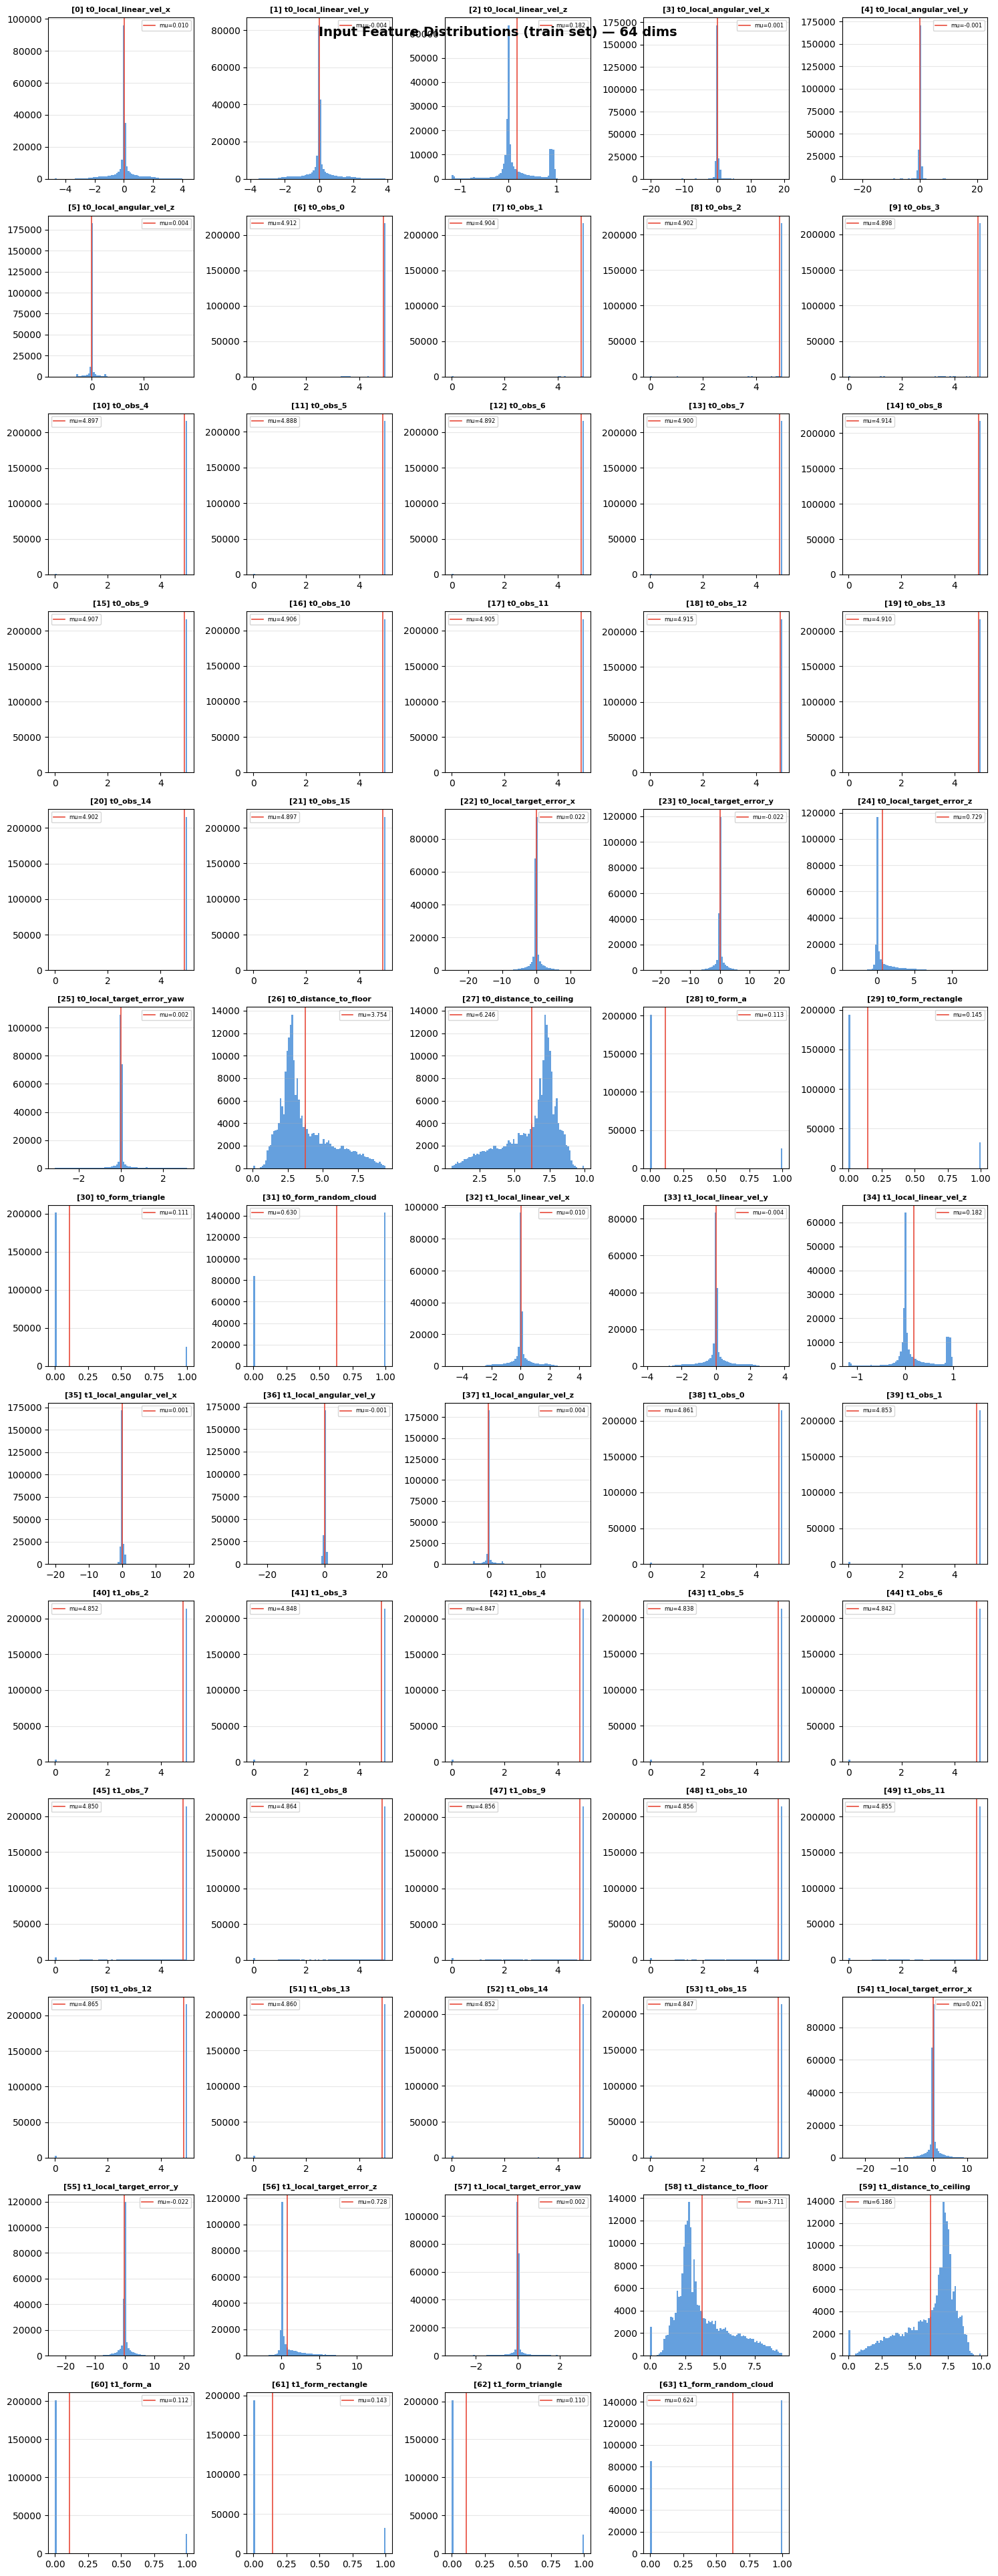

In [7]:
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

train_data = payload1["data"]
all_x_raw = train_data.x
num_features = all_x_raw.shape[1]
if "feature_names" not in globals():
    feature_names = [f"feature_{i}" for i in range(num_features)]
elif len(feature_names) < num_features:
    feature_names = feature_names + [f"feature_{i}" for i in range(len(feature_names), num_features)]
elif len(feature_names) > num_features:
    feature_names = feature_names[:num_features]

x_np = all_x_raw.detach().cpu().numpy()
cols = 5
rows = (num_features + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
axes = np.array(axes).reshape(rows, cols)
fig.suptitle(f"Input Feature Distributions (train set) — {num_features} dims",
             fontsize=14, fontweight="bold")

for i in range(rows * cols):
    ax = axes.flat[i]
    if i >= num_features:
        ax.axis("off")
        continue
    name = feature_names[i]
    col = x_np[:, i]
    if name.startswith("form_"):
        unique, counts = np.unique(col, return_counts=True)
        ax.bar(unique.astype(str), counts, color="#4a90d9", edgecolor="white")
    else:
        ax.hist(col, bins=80, color="#4a90d9", edgecolor="none", alpha=0.85)
        ax.axvline(col.mean(), color="#e74c3c", lw=1.2,
                   label=f"mu={col.mean():.3f}")
        ax.legend(fontsize=6)
    ax.set_title(f"[{i}] {name}", fontweight="bold", fontsize=8)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Target distribution
Label distribution for next-step local displacement.

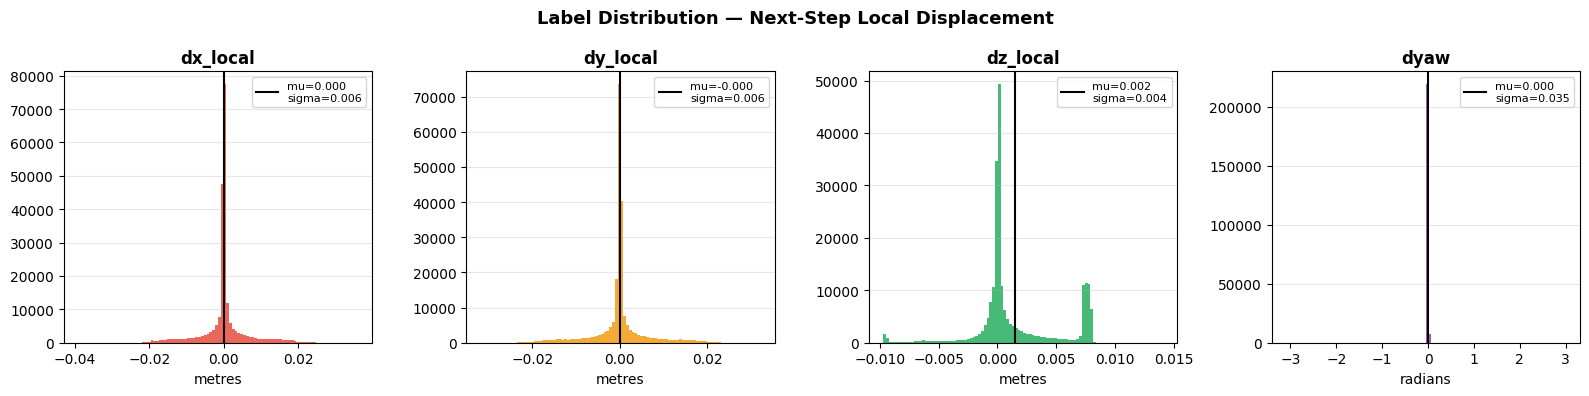

Displacement label stats:
  mean : [ 1.0e-04 -0.0e+00  1.5e-03  0.0e+00]
  std  : [0.0058 0.0059 0.0035 0.0348]
  min  : [-0.0393 -0.0319 -0.0097 -3.1074]
  max  : [0.0361 0.0323 0.0141 3.0067]


In [8]:
import numpy as np
import matplotlib.pyplot as plt

train_payload = payload1
data = train_payload["data"]
if not hasattr(data, "target"):
    raise AttributeError("Expected data.target in the new dataset format.")
all_target = data.target.detach().cpu().numpy()

label_names = ["dx_local", "dy_local", "dz_local", "dyaw"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Label Distribution — Next-Step Local Displacement",
             fontsize=13, fontweight="bold")

colors = ["#e74c3c", "#f39c12", "#27ae60", "#8e44ad"]
units  = ["metres", "metres", "metres", "radians"]
for i, (ax, name, color, unit) in enumerate(zip(axes, label_names, colors, units)):
    col = all_target[:, i]
    ax.hist(col, bins=100, color=color, edgecolor="none", alpha=0.85)
    ax.axvline(col.mean(), color="black", lw=1.5,
               label=f"mu={col.mean():.3f}\nsigma={col.std():.3f}")
    ax.set_title(f"{name}", fontweight="bold")
    ax.set_xlabel(unit)
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("Displacement label stats:")
print(f"  mean : {all_target.mean(0).round(4)}")
print(f"  std  : {all_target.std(0).round(4)}")
print(f"  min  : {all_target.min(0).round(4)}")
print(f"  max  : {all_target.max(0).round(4)}")


In [10]:
import torch
import numpy as np

if "payload1" not in globals():
    raise RuntimeError("Run the load data cell first.")

payload = payload1
data = payload["data"]
slices = payload["slices"]

episode_id_target = 80
episode_graph_rank = 500  # 1-based index within the episode
episode_graph_idx = episode_graph_rank - 1

def extract_graph(payload, idx=0):
    data = payload["data"]
    slices = payload["slices"]
    graph = {}
    for key, sl in slices.items():
        if not hasattr(data, key):
            continue
        item = getattr(data, key)
        graph[key] = item[sl[idx]:sl[idx + 1]]
    return graph

graph_idx = None
note = ""
if "episode_id" in slices and hasattr(data, "episode_id"):
    ep = data.episode_id
    sl = slices["episode_id"]
    episode_ids = [int(ep[sl[i]]) for i in range(len(sl) - 1)]
    episode_indices = [i for i, eid in enumerate(episode_ids) if eid == episode_id_target]
    if episode_indices:
        if 0 <= episode_graph_idx < len(episode_indices):
            graph_idx = episode_indices[episode_graph_idx]
            note = f"episode {episode_id_target} graph rank {episode_graph_rank}"
        else:
            graph_idx = episode_indices[-1]
            note = f"episode {episode_id_target} has {len(episode_indices)} graphs; using last"
    else:
        note = f"episode {episode_id_target} not found; using global graph 500"
else:
    note = "episode_id not available; using global graph 500"

if graph_idx is None:
    first_key = next(iter(slices))
    num_graphs = len(slices[first_key]) - 1
    graph_idx = min(500, num_graphs - 1)

graph = extract_graph(payload, graph_idx)
print(f"Selected graph index: {graph_idx} ({note})")

def print_scalar(label, value):
    if torch.is_tensor(value) and value.numel() == 1:
        print(f"{label}: {int(value.item())}")

print_scalar("episode_id", graph.get("episode_id"))
print_scalar("step_idx", graph.get("step_idx"))
print_scalar("formation_id", graph.get("formation_id"))
print_scalar("num_drones", graph.get("num_drones"))

def print_tensor_info(name, value):
    if torch.is_tensor(value):
        print(f"{name}: shape={tuple(value.shape)} dtype={value.dtype}")

print_tensor_info("x", graph.get("x"))
print_tensor_info("target", graph.get("target"))
print_tensor_info("edge_attr", graph.get("edge_attr"))
print_tensor_info("pos", graph.get("pos"))

x = graph.get("x")
if torch.is_tensor(x) and x.numel() > 0:
    num_features = x.shape[1]
    formation_names = list(payload.get("formation_names", []))
    obs_names = [f"obs_{i}" for i in range(16)]
    feature_names = [
        "local_linear_vel_x", "local_linear_vel_y", "local_linear_vel_z",
        "local_angular_vel_x", "local_angular_vel_y", "local_angular_vel_z",
        *obs_names,
        "local_target_error_x", "local_target_error_y", "local_target_error_z", "local_target_error_yaw",
    ]
    remaining = num_features - len(feature_names)
    if remaining > 0:
        if formation_names and len(formation_names) == remaining:
            feature_names.extend([f"form_{name}" for name in formation_names])
        else:
            feature_names.extend([f"feature_{i}" for i in range(len(feature_names), num_features)])
    elif remaining < 0:
        feature_names = feature_names[:num_features]

    first_drone = x[0].detach().cpu().numpy()
    print("\nFirst drone feature node:")
    for i, value in enumerate(first_drone):
        name = feature_names[i] if i < len(feature_names) else f"feature_{i}"
        print(f"  [{i}] {name}: {float(value):.6f}")

Selected graph index: 7606 (episode 80 has 100 graphs; using last)
episode_id: 80
step_idx: 990
formation_id: 3
num_drones: 18
x: shape=(18, 64) dtype=torch.float32
target: shape=(18, 4) dtype=torch.float32
edge_attr: shape=(130, 7) dtype=torch.float32
pos: shape=(18, 3) dtype=torch.float32

First drone feature node:
  [0] local_linear_vel_x: -0.024360
  [1] local_linear_vel_y: -0.066862
  [2] local_linear_vel_z: 0.000467
  [3] local_angular_vel_x: -0.000680
  [4] local_angular_vel_y: -0.000146
  [5] local_angular_vel_z: -0.000003
  [6] obs_0: 2.095191
  [7] obs_1: 1.888285
  [8] obs_2: 5.000000
  [9] obs_3: 5.000000
  [10] obs_4: 5.000000
  [11] obs_5: 5.000000
  [12] obs_6: 5.000000
  [13] obs_7: 5.000000
  [14] obs_8: 5.000000
  [15] obs_9: 5.000000
  [16] obs_10: 5.000000
  [17] obs_11: 5.000000
  [18] obs_12: 5.000000
  [19] obs_13: 5.000000
  [20] obs_14: 5.000000
  [21] obs_15: 5.000000
  [22] local_target_error_x: -0.047268
  [23] local_target_error_y: -0.149181
  [24] local_ta